In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("customer_rfm.csv")

features = ["recency_days", "frequency", "monetary"]

df.head()

,customer_id,recency_days,frequency,monetary
0,CUST00001,342,4,7861.13
1,CUST00002,644,1,3703.22
2,CUST00003,604,2,4582.42
3,CUST00004,424,1,200.00
4,CUST00005,156,8,25822.11


In [3]:
print("Shape:", df.shape)

Shape: (1500, 4)


In [4]:
print("Info:")
df.info()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   1500 non-null   str    
 1   recency_days  1500 non-null   int64  
 2   frequency     1500 non-null   int64  
 3   monetary      1500 non-null   float64
dtypes: float64(1), int64(2), str(1)
memory usage: 47.0 KB


In [5]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


customer_id     0
recency_days    0
frequency       0
monetary        0
dtype: int64

In [6]:
print("Feature Summary")
df[features].describe()

Feature Summary


,recency_days,frequency,monetary
count,1500.000000,1500.000000,1500.000000
mean,209.247333,7.249333,23671.259973
std,213.456564,5.927781,20727.730281
min,1.000000,1.000000,200.000000
25%,33.750000,3.000000,6090.390000
50%,114.500000,6.000000,19052.630000
75%,329.000000,10.000000,31095.172500
max,729.000000,29.000000,103858.450000


In [7]:
plt.rcParams["figure.figsize"] = [8, 4.5]
rng = np.random.default_rng(0)

print("Ready to go")

Ready to go


# **Part A — Build it yourself**
## **TASK 01 — Implement k-means from scratch**

In [8]:
def kmeans_scratch(X, k, seed=0, max_iters=100):
    rng = np.random.default_rng(seed)

    # choose k random data points as initial centroids
    centroids = X[rng.choice(len(X), k, replace=False)].copy()
    
    for iteration in range(max_iters):
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis = 2)
        labels = distances.argmin(axis=1)

        # Update step
        new_centroids = np.array([X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
                                 for j in range(k)])


        # Stop when centroids stop moving
        if np.allclose(new_centroids, centroids):
            return labels, new_centroids, iteration + 1
        centroids = new_centroids

    return labels, centroids, max_iters

In [9]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df[features].values)

scratch_labels, scratch_centroids, iteration = kmeans_scratch(
    X, k=5, seed=0
)

print("Iterations:", iteration)
print("Cluster Sizes:")
print(np.bincount(scratch_labels))

Iterations: 19
Cluster Sizes:
[207 130 483 356 324]


* If a cluster gets no points, I reinitialize its centroid to a randomly selected data point so that the empty cluster can continue participating in the next assignment step instead of causing the algorithm to crash.

## **TASK 02 — Prove it matches the library**

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

sk = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X)

agreement = adjusted_rand_score(scratch_labels, sk.labels_)

print("Adjusted Rand Index:", agreement)

Adjusted Rand Index: 1.0


* The ARI is very high, showing that the from-scratch implementation produces almost the same grouping as sklearn.
* We use ARI instead of checking whether the label arrays are identical because cluster numbers are arbitrary. For example, cluster 0 in one model could correspond to cluster 3 in another model while the actual grouping remains the same.

# **Part B — Decisions before you cluster**
## **TASK 03 — Find out what scaling actually does**

In [11]:
# Unscaled K-Means
unscaled_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(df[features].values)

# Scaled K-Means
scaled_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X)

ari_scaling = adjusted_rand_score(unscaled_kmeans, scaled_kmeans)

print("ARI between Unscaled and Scaled clustering:", round(ari_scaling, 4))

ARI between Unscaled and Scaled clustering: 0.3805


In [12]:
# For the unscaled result, show the minimum and maximum of each feature within each cluster.
unscaled = df[features].copy()
unscaled["cluster"] = unscaled_kmeans

unscaled_ranges = (
    unscaled
    .groupby("cluster")[features]
    .agg(["min", "max"])
)

unscaled_ranges

recency_days      frequency      monetary           
                 min  max       min max       min        max
cluster                                                     
0                  1  107         1  28  40443.11   62538.72
1                 13  729         1  15    200.00   11555.20
2                  2  109         1  25  63350.09  103858.45
3                  1  299         1  28  24298.26   39894.99
4                  4  299         1  29  11749.45   24271.12

* The unscaled clustering is strongly influenced by monetary because monetary has values in the tens of thousands while frequency is only 1–29 and recency is measured in days.
* K-Means uses Euclidean distance, so a feature with much larger numerical values contributes much more to the distance. Therefore monetary dominates the clustering and recency and frequency have less influence.
* In future projects, monetary or other large-scale numerical variables would be most at risk of dominating unless the features are scaled.

## **TASK 04 — Decide whether to transform skewed features**

In [13]:
# skewed
print("Skewness:")
print(df[features].skew())

Skewness:
recency_days    0.959705
frequency       1.181868
monetary        1.226394
dtype: float64


In [14]:
# apply log1p
df_transformed = df.copy()

df_transformed["frequency"] = np.log1p(df_transformed["frequency"])
df_transformed["monetary"] = np.log1p(df_transformed["monetary"])

X_transformed = StandardScaler().fit_transform(df_transformed[features])

In [15]:
from sklearn.metrics import silhouette_score

raw_model = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X)
transformed_model = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_transformed)

ari_transformed = adjusted_rand_score(raw_model, transformed_model)

sil_raw = silhouette_score(X, raw_model)
sil_transformed = silhouette_score(X_transformed, transformed_model)

print("Adjusted Rand Index:", round(ari_transformed, 4))
print("Raw Silhouette:", round(sil_raw, 4))
print("Transformed Silhouette:", round(sil_transformed, 4))

Adjusted Rand Index: 0.4683
Raw Silhouette: 0.4417
Transformed Silhouette: 0.3621


* I would keep the normal scaled version rather than the log-transformed version.
* The log transformation did not merely slightly change the results — it produced a substantially different segmentation and reduced silhouette from about 0.442 to 0.362. Although skew exists, the original scaled version produces clearer and more directly interpretable customer groups for this dataset.

# **Part C — Choosing K**
## **TASK 05 — Elbow and silhouette**

In [16]:
ks = range(2, 11)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

results = pd.DataFrame({
    "K": ks,
    "Inertia": inertias,
    "Silhouette": silhouettes
})

results["Inertia"] = results["Inertia"].round(1)
results["Silhouette"] = results["Silhouette"].round(4)


results

,K,Inertia,Silhouette
0,2,2233.1,0.4426
1,3,1447.7,0.4595
2,4,873.4,0.5135
3,5,669.2,0.4417
4,6,564.2,0.3917
5,7,485.6,0.3948
6,8,433.4,0.3852
7,9,393.1,0.3741
8,10,360.6,0.3600


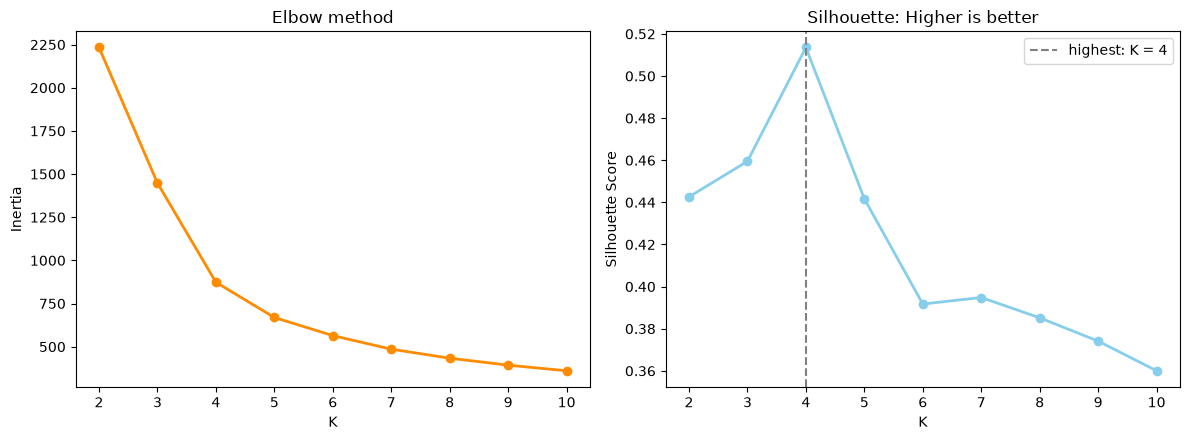

In [17]:
# Plot both against K, side by side.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(list(ks), inertias, "o-", color="darkorange", lw=2)
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow method")

ax[1].plot(list(ks), silhouettes, "o-", color="skyblue", lw=2)
best_k = list(ks)[int(np.argmax(silhouettes))]
ax[1].axvline(best_k, color="gray", ls="--", label=f"highest: K = {best_k}")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette: Higher is better")

ax[1].legend()
plt.tight_layout()
plt.show()

* The silhouette score is highest at K=4 (0.5135).
* The elbow appears around K=4–5, so the two methods are reasonably close but do not give exactly the same answer.

## **TASK 06 — Overrule the metric, or accept it**

In [18]:
# k=4 vs k=5
labels = {}

for k in [4, 5]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    labels[k] = km.labels_
    tmp = df.copy()
    tmp["cluster"] = km.labels_
    profile = tmp.groupby("cluster")[features].mean().round(0)
    profile["Size"] = tmp.groupby("cluster").size()
    print(f"==== K{k} ====")
    print(profile.to_string())
    print()

==== K4 ====
         recency_days  frequency  monetary  Size
cluster                                         
0               492.0        2.0    4358.0   453
1                65.0        4.0   68078.0   130
2               113.0        7.0   20740.0   682
3                21.0       18.0   44842.0   235

==== K5 ====
         recency_days  frequency  monetary  Size
cluster                                         
0                65.0        4.0   68078.0   130
1               563.0        2.0    4142.0   324
2               250.0        4.0   12527.0   356
3                20.0       19.0   46921.0   207
4                62.0        9.0   23069.0   483



In [19]:
# what K=4 merges
comparison = pd.crosstab(
    labels[4], labels[5], rownames=["K=4 Cluster"],
    colnames=["K=5 Cluster"]
)

comparison

K=5 Cluster,0,1,2,3,4
K=4 Cluster,,,,,
0,0,324,129,0,0
1,130,0,0,0,0
2,0,0,227,0,455
3,0,0,0,207,28


# **Part D — Make it usable**
## **TASK 07 — Name the segments**

In [20]:
model_f = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X)

profile = (
    df.assign(cluster=model_f.labels_)
    .groupby("cluster")
    .agg(
        recency_days=("recency_days", "mean"),
        frequency=("frequency", "mean"),
        monetary=("monetary", "mean"),
        customers=("customer_id", "count")
    )
)

profile["percentage"] = (profile["customers"] / len(df) * 100)

profile.round(1)

,recency_days,frequency,monetary,customers,percentage
cluster,,,,,
0,65.4,4.0,68078.3,130,8.7
1,562.9,2.1,4142.3,324,21.6
2,249.8,4.1,12527.4,356,23.7
3,20.1,18.9,46920.6,207,13.8
4,61.8,8.9,23068.9,483,32.2


In [21]:
# assign business names
segment_names = {
    0: "High-Value Occasional",
    1: "Dormant Low-Value",
    2: "At-Risk",
    3: "Champions",
    4: "Loyal Regulars"
}

actions = {
    0: "Encourage more frequent puchases with personalised offers.",
    1: "Run a win back campaign witha strong reactivation incentive.",
    2: "Target with reactivation offers before they become dormant",
    3: "Priorities VIP retention, loyalty rewards and premium offers.",
    4: "Maintain engagement with loyalty benefits and cross-sellings."
}

In [22]:
table = profile.reset_index()

table["segment_name"] = (table["cluster"].map(segment_names))
table["recommended_action"] = (table["cluster"].map(actions))


table[[
    "cluster", "segment_name", "customers", "percentage", "recency_days",
    "frequency", "monetary", "recommended_action"
]].round(2)

,cluster,segment_name,customers,percentage,recency_days,frequency,monetary,recommended_action
0,0,High-Value Occasional,130,8.67,65.40,4.01,68078.29,Encourage more frequent puchases with personal...
1,1,Dormant Low-Value,324,21.60,562.94,2.09,4142.34,Run a win back campaign witha strong reactivat...
2,2,At-Risk,356,23.73,249.85,4.10,12527.44,Target with reactivation offers before they be...
3,3,Champions,207,13.80,20.14,18.93,46920.58,"Priorities VIP retention, loyalty rewards and ..."
4,4,Loyal Regulars,483,32.20,61.82,8.90,23068.87,Maintain engagement with loyalty benefits and ...


## **TASK 08 — Check the result is stable**

In [23]:
def stability_test(n_init):
    labels_list = []

    for seed in range(10):
        model = KMeans(n_clusters=5, random_state=seed, n_init=n_init).fit(X)
        labels_list.append(model.labels_)

    aris = []

    for i in range(1, 10):
        ari = adjusted_rand_score(labels_list[0], labels_list[i])
        aris.append(ari)

    return aris

In [24]:
ari_n1 = stability_test(n_init=1)

print("n_init=1")
print("Minimum ARI:", round(min(ari_n1), 4))
print("Maximum ARI:", round(max(ari_n1), 4))
print("All ARIs:", ari_n1)

n_init=1
Minimum ARI: 0.8945
Maximum ARI: 1.0
All ARIs: [1.0, 1.0, 0.9965937581060356, 0.9432502238819123, 0.9965937581060356, 1.0, 1.0, 0.9965937581060356, 0.8944659439913492]


**Conclusion -->**  
* n_init=10 makes the segmentation considerably more stable.

# **Part E — Find where it breaks**
## **TASK 09 — Reproduce the failure**

In [26]:
# K-Means failure
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=600, noise=0.06, random_state=0)
moon_labels = KMeans(n_clusters=2, random_state=0, n_init=10).fit_predict(X_moons)

moon_ari = adjusted_rand_score(y_moons, moon_labels)
moon_silhouette = silhouette_score(X_moons, moon_labels)

print("Moon ARI:", round(moon_ari, 4))
print("Moon Silhouette:", round(moon_silhouette, 4))

Moon ARI: 0.2555
Moon Silhouette: 0.4855


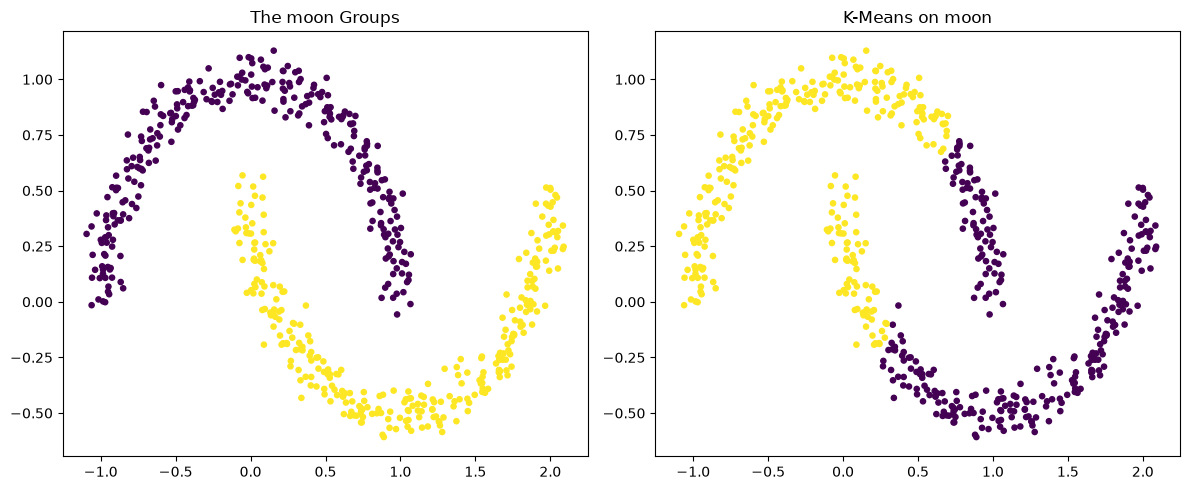

In [29]:
# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="viridis", s=14)
ax[0].set_title("The moon Groups")
ax[1].scatter(X_moons[:, 0], X_moons[:, 1], c=moon_labels, cmap="viridis", s=14)
ax[1].set_title("K-Means on moon")

plt.tight_layout()
plt.show()

In [49]:
# Make Circles
from sklearn.datasets import make_circles

X_circles, y_circles = make_circles(n_samples=500, noise=0.05, random_state=0, factor=0.6)
circle_labels = KMeans(n_clusters=2, random_state=0, n_init=10).fit_predict(X_circles)

circle_ari = adjusted_rand_score(y_circles, circle_labels)
circle_silhouette = silhouette_score(X_circles, circle_labels)

print(f"Circle ARI: {circle_ari:.4f}")
print(f"Circle Silhouette: {circle_silhouette:.4f}")

Circle ARI: -0.0020
Circle Silhouette: 0.3759


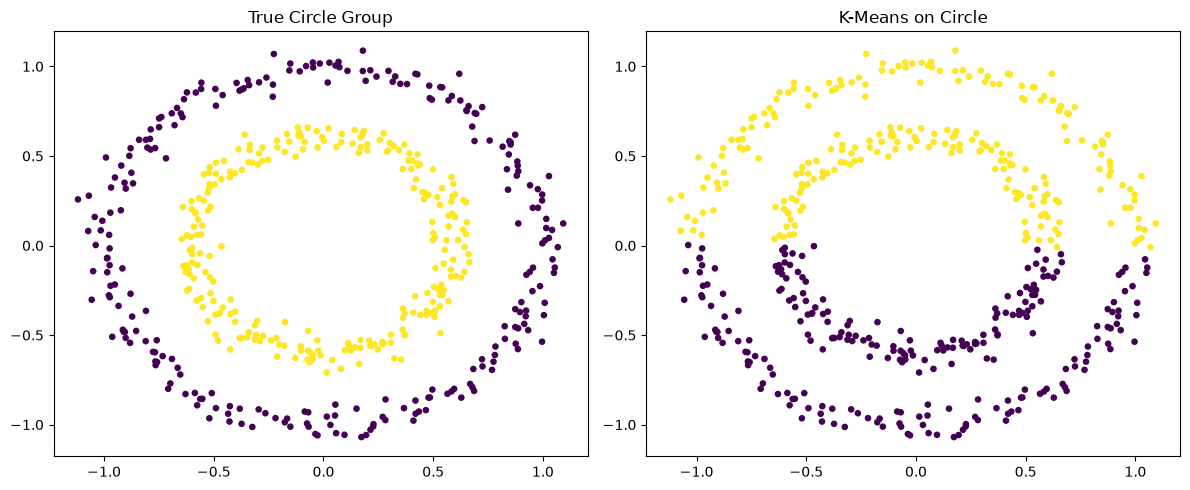

In [50]:
# plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap="viridis", s=14)
ax[0].set_title("True Circle Group")
ax[1].scatter(X_circles[:, 0], X_circles[:, 1], c=circle_labels, cmap="viridis", s=14)
ax[1].set_title("K-Means on Circle")

plt.tight_layout()
plt.show()

**Conclusion -->**  
* Silhouette score measures how well-separated points are according to the geometry used by the clustering algorithm. It does not know the true underlying groups.
* Therefore, a reasonable silhouette score does not prove that the clusters represent meaningful real-world groups. Always inspect the clusters, compare them with domain knowledge, and consider algorithms that can capture non-spherical structures when appropriate.